# Лабораторрная работа 4

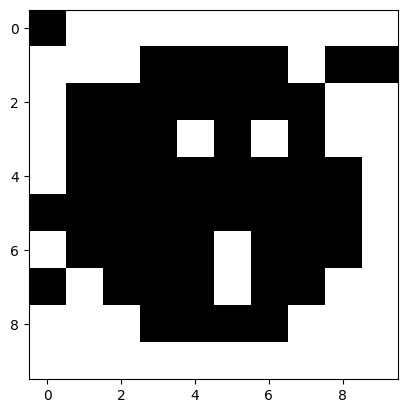

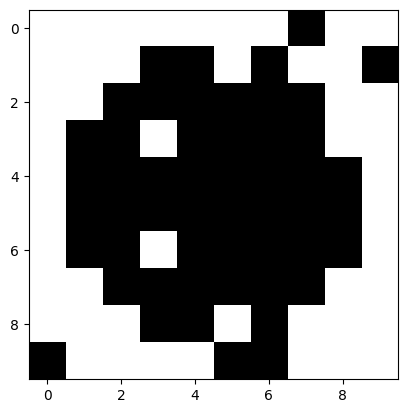

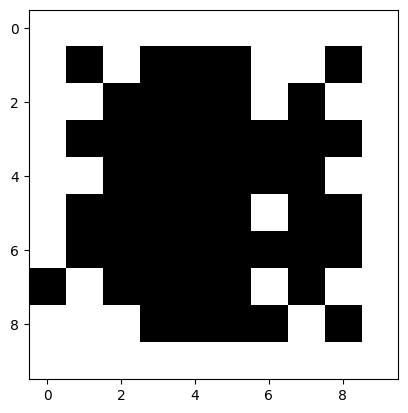

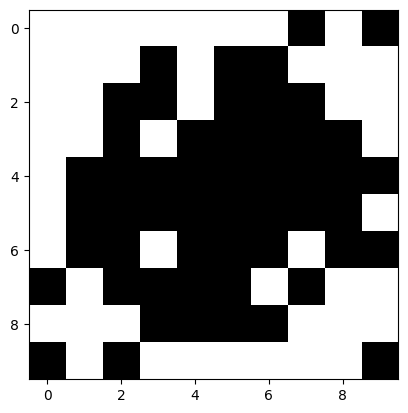

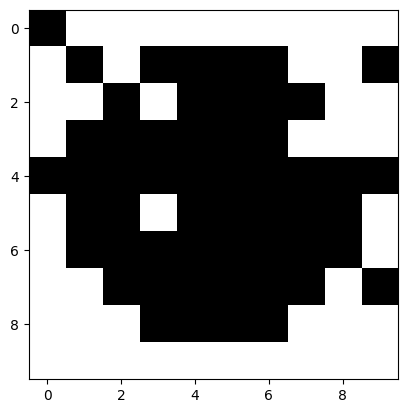

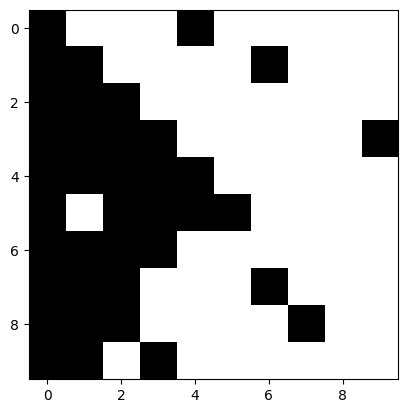

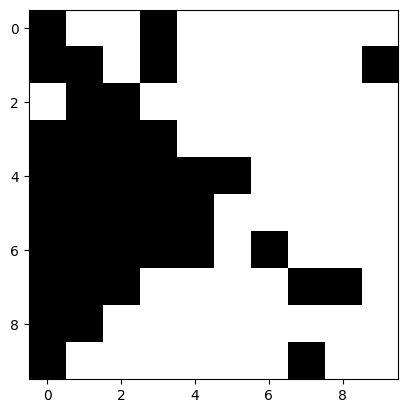

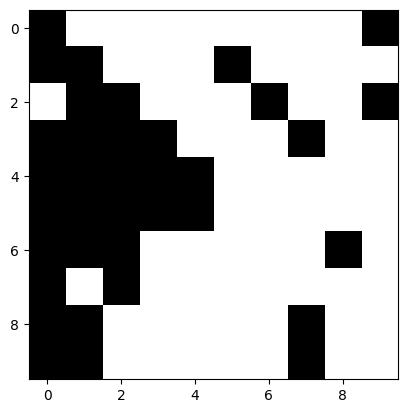

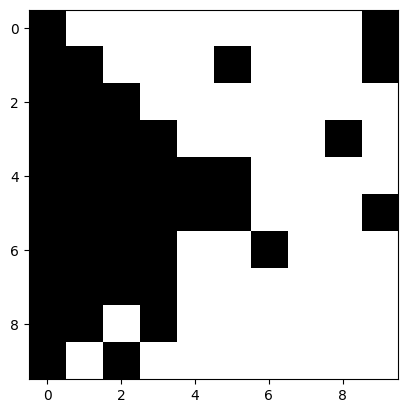

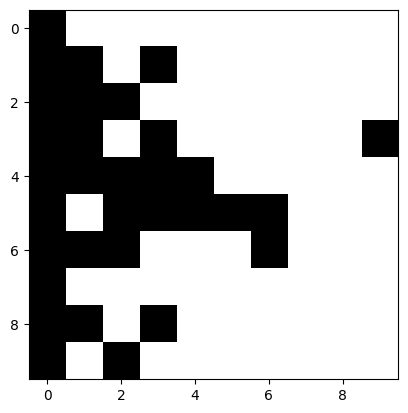

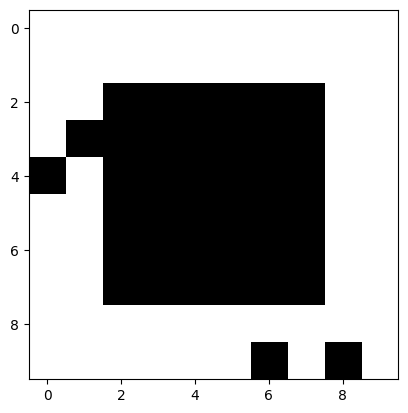

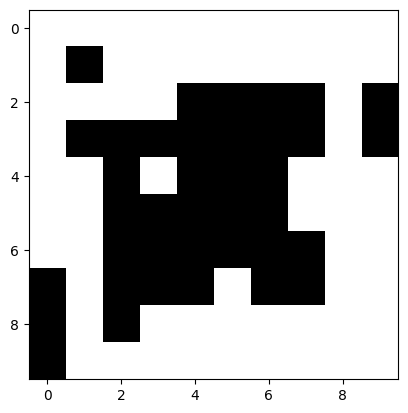

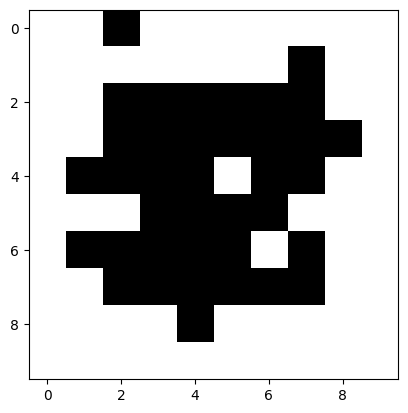

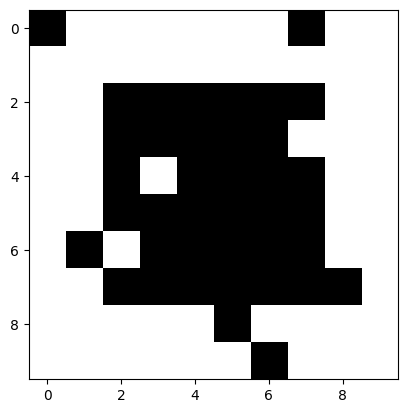

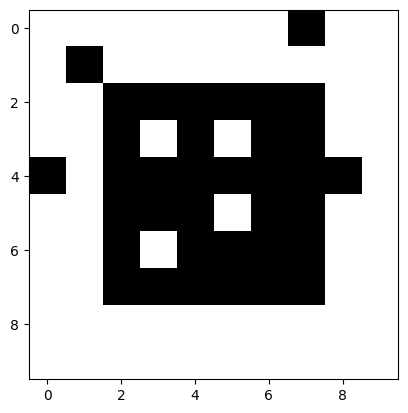

Введите изображение 10x10 (0 или 1, разделенные пробелами):


KeyboardInterrupt: Interrupted by user

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Определим три образа: круг, треугольник и квадрат (10x10)
def create_circle():
    circle = np.zeros((10, 10))
    for i in range(10):
        for j in range(10):
            if (i - 4.5)**2 + (j - 4.5)**2 <= 16:  # Радиус круга
                circle[i, j] = 1
    return circle

def create_triangle():
    triangle = np.zeros((10, 10))
    for i in range(10):
        for j in range(10):
            if i >= j and i + j <= 9:  # Условие для треугольника
                triangle[i, j] = 1
    return triangle

def create_square():
    square = np.zeros((10, 10))
    square[2:8, 2:8] = 1  # Внутренняя часть квадрата
    return square

# 2. Определим обучающую выборку для каждого из образов
def generate_training_set(base_image, num_images=5):
    training_set = []
    for _ in range(num_images):
        noise = np.random.choice([0, 1], size=base_image.shape, p=[0.1, 0.9])  # Добавляем шум
        noisy_image = np.logical_xor(base_image, noise).astype(int)
        training_set.append(noisy_image)
        plt.imshow(noisy_image, cmap='gray', interpolation='none')
        plt.show()

    return training_set

circle_set = generate_training_set(create_circle())
triangle_set = generate_training_set(create_triangle())
square_set = generate_training_set(create_square())

# 3. Зададим распознаваемое изображение (10x10)
def get_user_image():
    print("Введите изображение 10x10 (0 или 1, разделенные пробелами):")
    image = []
    for _ in range(10):
        row = list(map(int, input().split()))
        if len(row) != 10:
            raise ValueError("Каждая строка должна содержать ровно 10 чисел.")
        image.append(row)
    return np.array(image)

# 4. Определим расстояние по Хэммингу
def hamming_distance(img1, img2):
    return np.sum(img1 != img2)

# 5. Определим потенциал, создаваемый каждым из образов
def calculate_potential(image, training_set):
    distances = 1000000/(1+np.sum([hamming_distance(image, train_image) for train_image in training_set])^2)
    return distances

# 6. Распознавание изображения
def recognize_image(image):
    potentials = {
        "Circle": calculate_potential(image, circle_set),
        "Triangle": calculate_potential(image, triangle_set),
        "Square": calculate_potential(image, square_set)
    }
    recognized_shape = max(potentials, key=potentials.get)
    return recognized_shape, potentials

# Основная программа
if __name__ == "__main__":
    try:
        user_image = get_user_image()
        recognized_shape, potentials = recognize_image(user_image)

        print("\nРаспознанное изображение:")
        plt.imshow(user_image, cmap='gray')
        plt.show()

        print("\nПотенциалы:")
        for shape, potential in potentials.items():
            print(f"{shape}: {potential}")

        print(f"\nРаспознанный образ: {recognized_shape}")
    except ValueError as e:
        print
        (f"Ошибка: {e}")

In [ ]:
import numpy as np

# 1. Определим три образа: круг, треугольник и квадрат (10x10)
def create_circle():
    circle = np.zeros((10, 10))
    for i in range(10):
        for j in range(10):
            if (i - 4.5)**2 + (j - 4.5)**2 <= 16:  # Радиус круга
                circle[i, j] = 1
    return circle

def create_triangle():
    triangle = np.zeros((10, 10))
    for i in range(10):
        for j in range(10):
            if i >= j and i + j <= 9:  # Условие для треугольника
                triangle[i, j] = 1
    return triangle

def create_square():
    square = np.zeros((10, 10))
    square[2:8, 2:8] = 1  # Внутренняя часть квадрата
    return square

# 2. Определим обучающую выборку для каждого из образов
def generate_training_set(base_image, num_images=5):
    training_set = []
    for _ in range(num_images):
        noise = np.random.choice([0, 1], size=base_image.shape, p=[0.1, 0.9])  # Добавляем шум
        noisy_image = np.logical_xor(base_image, noise).astype(int)
        training_set.append(noisy_image)
    return training_set

# 3. Определим расстояние по Хэммингу
def hamming_distance(img1, img2):
    return np.sum(img1 != img2)

# 4. Определим потенциал, создаваемый каждым из образов
def calculate_potential(image, training_set):
    distances = 1000000 / (1 + np.sum([hamming_distance(image, train_image) for train_image in training_set]) ** 2)
    return distances

# 5. Распознавание изображения
def recognize_image(image, circle_set, triangle_set, square_set):
    potentials = {
        "Circle": calculate_potential(image, circle_set),
        "Triangle": calculate_potential(image, triangle_set),
        "Square": calculate_potential(image, square_set)
    }
    recognized_shape = max(potentials, key=potentials.get)
    return recognized_shape

# 6. Вшитые изображения для дополнительного тестирования
def get_embedded_images():
    # Примеры вшитых изображений с их предполагаемыми названиями
    embedded_images = [
        {"image": np.array([
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        ]), "true_label": "Circle"},
        {"image": np.array([
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
            [0, 0, 0, 1, 1, 1, 1, 0, 0, 0],
            [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
            [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
            [0, 0, 0, 1, 1, 1, 1, 0, 0, 0],
            [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        ]), "true_label": "Triangle"},
        {"image": np.array([
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 1, 1, 1, 1, 1, 0, 0],
            [0, 0, 0, 1, 1, 1, 1, 1, 0, 0],
            [0, 0, 0, 1, 1, 1, 1, 1, 0, 0],
            [0, 0, 0, 1, 1, 1, 0, 1, 1, 0],
            [0, 0, 0, 1, 0, 1, 1, 1, 0, 0],
            [0, 0, 0, 1, 1, 1, 1, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        ]), "true_label": "Square"},
        {"image": np.array([
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
            [0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
            [0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
            [0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
            [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        ]), "true_label": "Circle"},
        {"image": np.array([
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
            [0, 0, 0, 1, 1, 1, 1, 0, 0, 0],
            [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        ]), "true_label": "Triangle"},
        {"image": np.array([
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, 1, 1, 1, 0, 0, 0, 0],
            [0, 0, 1, 1, 1, 1, 1, 0, 0, 0],
            [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
            [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
            [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
            [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
        ]), "true_label": "Square"}
    ]
    return embedded_images

# Основная программа
if __name__ == "__main__":
    # Генерация обучающих наборов
    circle_set = generate_training_set(create_circle())
    triangle_set = generate_training_set(create_triangle())
    square_set = generate_training_set(create_square())

    # Получение вшитых изображений
    embedded_images = get_embedded_images()

    # Тестирование вшитых изображений
    correct_count = 0
    for i, item in enumerate(embedded_images):
        image = item["image"]
        true_label = item["true_label"]
        recognized_shape = recognize_image(image, circle_set, triangle_set, square_set)
        print(f"Изображение {i + 1}: Ожидалось: {true_label}, Распознано: {recognized_shape}")
        if recognized_shape == true_label:
            correct_count += 1

    # Вычисление процента совпадения
    recognition_rate = (correct_count / len(embedded_images)) * 100
    print(f"\nПроцент совпадения распознанных фигур с их названиями: {recognition_rate:.2f}%")

Изображение 1: Ожидалось: Circle, Распознано: Circle
Изображение 2: Ожидалось: Triangle, Распознано: Triangle
Изображение 3: Ожидалось: Square, Распознано: Triangle
Изображение 4: Ожидалось: Circle, Распознано: Circle
Изображение 5: Ожидалось: Triangle, Распознано: Circle
Изображение 6: Ожидалось: Square, Распознано: Triangle

Процент совпадения распознанных фигур с их названиями: 50.00%


0 0 0 0 1 1 0 0 0 0
0 0 0 0 1 1 0 0 0 0
0 0 0 1 1 1 1 0 0 0
0 0 0 1 1 1 1 0 0 0
0 0 1 1 1 1 1 1 0 0
0 0 1 1 1 1 1 1 0 0
0 1 1 1 1 1 1 1 1 0
0 1 1 1 1 1 1 1 1 0
1 1 1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1 1 1
0 0 0 0 0 0 0 0 0 0
0 1 0 1 0 1 0 1 0 1

0 0 0 0 0 0 0 0 0 0
0 1 1 1 1 1 1 1 1 0
0 1 1 1 1 1 1 1 1 0
0 1 1 1 1 1 1 1 1 0
0 1 1 1 1 1 1 1 1 0
0 1 1 1 1 1 1 1 1 0
0 1 1 1 1 1 1 1 1 0
0 1 1 1 1 1 1 1 1 0
0 1 1 1 1 1 1 1 1 0
0 0 0 0 0 0 0 0 0 0

0 0 0 0 0 0 0 0 0 0
0 0 0 1 1 1 1 0 0 0
0 0 1 1 1 1 1 1 0 0
0 1 1 1 1 1 1 1 1 0
0 1 1 1 0 0 1 1 1 0
0 1 1 1 0 0 1 1 1 0
0 1 1 1 1 1 1 1 1 0
0 0 1 1 1 1 1 1 0 0
0 0 0 1 1 1 1 0 0 0
0 0 0 0 0 0 0 0 0 0


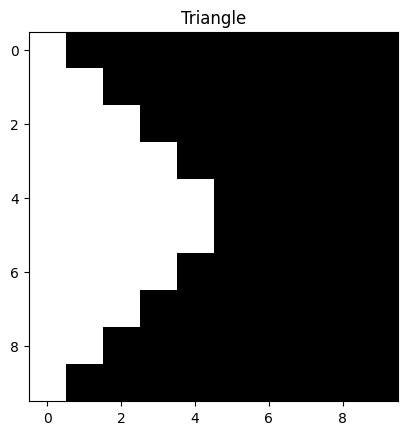

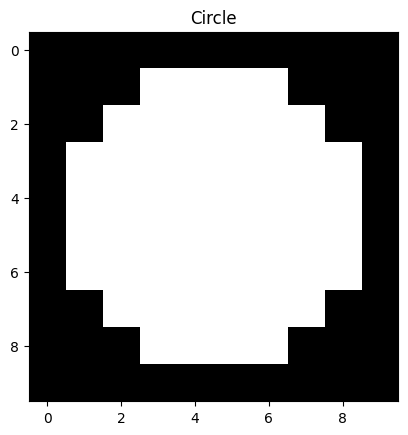

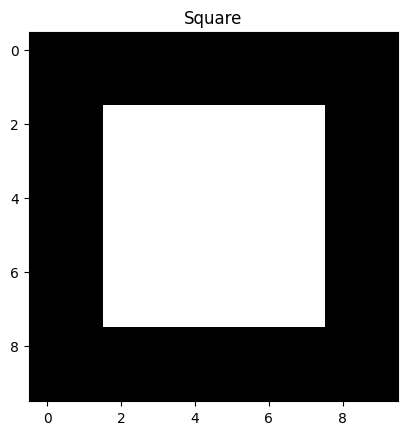

In [ ]:
# Создаем фигуры
triangle = create_triangle()
circle = create_circle()
square = create_square()

# Визуализируем фигуры
plt.imshow(triangle, cmap='gray', interpolation='none')
plt.title("Triangle")
plt.show()

plt.imshow(circle, cmap='gray', interpolation='none')
plt.title("Circle")
plt.show()

plt.imshow(square, cmap='gray', interpolation='none')
plt.title("Square")
plt.show()

# Лабораторрная работа 5

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2145 - loss: 2.0702
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2456 - loss: 2.0910 
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2421 - loss: 2.0798     
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2482 - loss: 2.0596 
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3548 - loss: 2.0101 
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4265 - loss: 2.0002 
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3605 - loss: 2.0040 
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3726 - loss: 1.9710 
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3800 - loss: 1.9701  
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3855 - loss: 1.9516 
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3586 - loss: 1.9634  
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accur

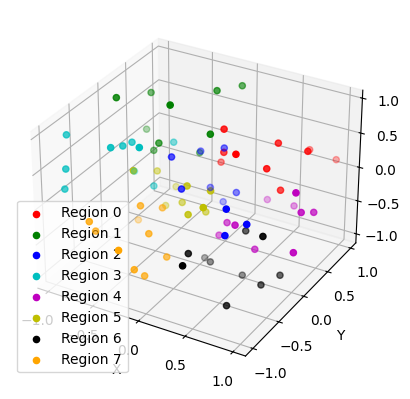

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Region 0:
[[ 0.70807258  0.29122914  0.04645041]
 [ 0.34106635 -0.90689723 -0.35796835]
 [ 0.25794163 -0.66097021 -0.39357094]
 [ 0.65998405 -0.65079043 -0.99080295]
 [ 0.8172222  -0.27404432 -0.89852846]]
Region 1:
[[ 0.15599452  0.18340451  0.78517596]
 [ 0.05808361  0.30424224  0.19967378]
 [-0.39245515  0.12203823  0.96958463]
 [-0.82947588  0.49517691  0.77513282]
 [-0.93494841  0.03438852  0.93949894]
 [-0.05111446  0.9093204   0.89482735]
 [-0.03436797  0.25877998  0.59789998]
 [-0.19160265  0.66252228  0.92187424]
 [-0.69538623  0.31171108  0.0884925 ]
 [-0.90232789  0.52006802  0.19598286]
 [-0.31576697  0.54671028  0.04522729]
 [-0.55984751  0.18485446  0.32533033]
 [-0.22903282 -0.09243353  0.63340376]]
Region 2:
[[ 0.37454012  0.02058449  0.61185289]
 [ 0.59865848  0.21233911  0.36636184]
 [ 0.15601864  0.18182497  0.45606998]
 [ 0.86617615  0.52475643  0.51423444]
 [ 0.60111501  0.43194502  0.59241457]
 [ 0.38867729 -0.22775523  0.8631

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Генерация случайных точек в каждой из 8 областей
np.random.seed(42)
points_per_region = 10
regions = 8
data = []
labels = []

for i in range(regions):
    x = np.random.uniform(-1 if i & 1 else 0, 0 if i & 1 else 1, points_per_region)
    y = np.random.uniform(-1 if i & 2 else 0, 0 if i & 2 else 1, points_per_region)
    z = np.random.uniform(-1 if i & 4 else 0, 0 if i & 4 else 1, points_per_region)
    region_points = np.column_stack((x, y, z))
    data.append(region_points)
    labels.extend([i] * points_per_region)

data = np.vstack(data)
labels = np.array(labels)

# Преобразование меток в one-hot encoding
labels_one_hot = tf.keras.utils.to_categorical(labels, num_classes=regions)

# Создание модели персептрона
model = Sequential([
    Dense(10, input_shape=(3,), activation='relu'),
    Dense(8, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Обучение модели
model.fit(data, labels_one_hot, epochs=50, batch_size=8, verbose=1)

# Визуализация точек на осях координат
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange']

for i in range(regions):
    region_points = data[labels == i]
    ax.scatter(region_points[:, 0], region_points[:, 1], region_points[:, 2], c=colors[i], label=f'Region {i}')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

# Распознавание регионов с помощью обученной модели
predictions = model.predict(data)
predicted_regions = np.argmax(predictions, axis=1)

# Вывод массива точек по распознанным регионам
for i in range(regions):
    print(f"Region {i}:")
    print(data[predicted_regions == i])

# Функция для использования обученной модели
def predict_region(x, y, z):
    point = np.array([[x, y, z]])
    prediction = model.predict(point)
    return np.argmax(prediction)

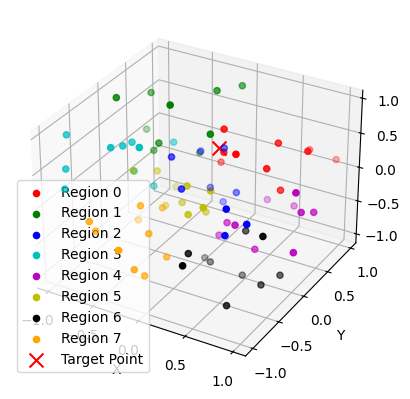

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted region for point: 1


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Координаты для крестика
x, y, z = -0.3, 0.9, -0.1  # Пример координат

# Визуализация точек на осях координат
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k', 'orange']

for i in range(regions):
    region_points = data[labels == i]
    ax.scatter(region_points[:, 0], region_points[:, 1], region_points[:, 2], c=colors[i], label=f'Region {i}')

# Добавление крестика на график
ax.scatter(x, y, z, c='red', marker='x', s=100, label='Target Point')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

# Предсказываем регион
print("Predicted region for point:", predict_region(x, y, z))

# Лабораторрная работа 6

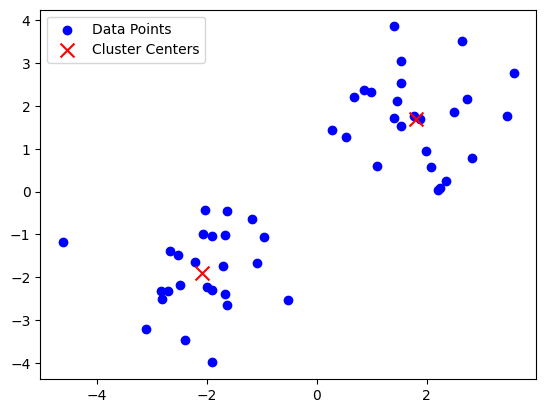

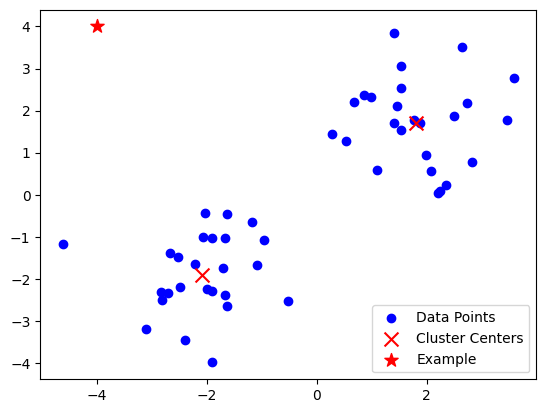

Точка [-4  4] принадлежит кластеру 0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Генерация случайных точек вокруг двух центров кластеризации
np.random.seed(42)
cluster1 = np.random.randn(25, 2) + np.array([2, 2])
cluster2 = np.random.randn(25, 2) + np.array([-2, -2])
data = np.vstack((cluster1, cluster2))

# Инициализация весов сети Кохонена
weights = np.random.rand(2, 2)

# Функция для вычисления расстояния между точками
def euclidean_distance(a, b):
    return np.linalg.norm(a - b)

# Процедура обучения сети Кохонена
def train_kohonen(data, weights, epochs=50):
    for i in range(epochs):
        alpha = (50 - i) / 100
        for point in data:
            # Находим выигравший нейрон (ближайший к точке)
            distances = np.array([euclidean_distance(point, w) for w in weights])
            winner = np.argmin(distances)

            # Обновляем веса выигравшего нейрона
            weights[winner] += alpha * (point - weights[winner])
    return weights

# Обучение сети
trained_weights = train_kohonen(data, weights)

# Визуализация результатов кластеризации
def plot_clusters(data, weights):
    plt.scatter(data[:, 0], data[:, 1], c='blue', label='Data Points')
    plt.scatter(weights[:, 0], weights[:, 1], c='red', marker='x', s=100, label='Cluster Centers')
    plt.legend()
    plt.show()

# Визуализация результатов кластеризации + точка
def plot_clusters_dot(data, weights, x, y):
    plt.scatter(data[:, 0], data[:, 1], c='blue', label='Data Points')
    plt.scatter(weights[:, 0], weights[:, 1], c='red', marker='x', s=100, label='Cluster Centers')
    plt.scatter(x, y, c='red', marker='*', s=100, label='Example')
    plt.legend()
    plt.show()
plot_clusters(data, trained_weights)

# Функция для определения кластера для новой точки
def predict_cluster(point, weights):
    distances = np.array([euclidean_distance(point, w) for w in weights])
    return np.argmin(distances)

# Пример использования обученной сети
x, y = -4, 4,  # Пример координат
new_point = np.array([x, y])
cluster = predict_cluster(new_point, trained_weights)
plot_clusters_dot(data, trained_weights, x, y)
print(f"Точка {new_point} принадлежит кластеру {cluster}")